In [66]:
import os 
import re 
import glob 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import tensorflow as tf
import keras

from sklearn.preprocessing import StandardScaler
seed = 42




In [39]:
tf.keras.utils.set_random_seed(seed)

In [40]:
zip_path = tf.keras.utils.get_file(
    origin = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname = 'jena_climate_2009.csv.zip',
    extract=True
)

extract_path = zip_path.replace('.zip','_extracted')
#buscamos el csv
csv_path = os.path.join(extract_path,'jena_climate_2009_2016.csv')
df = pd.read_csv(csv_path)
## ruta de guardado
print('Ruta CSV : ',csv_path)
print('Forma del Dataset: ',df.shape)
print(df.head)

Ruta CSV :  C:\Users\6570\.keras\datasets\jena_climate_2009_extracted\jena_climate_2009_2016.csv
Forma del Dataset:  (420551, 15)
<bound method NDFrame.head of                   Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  \
0       01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90   
1       01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28   
2       01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31   
3       01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07   
4       01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04   
...                     ...       ...       ...       ...          ...   
420546  31.12.2016 23:20:00   1000.07     -4.05    269.10        -8.13   
420547  31.12.2016 23:30:00    999.93     -3.35    269.81        -8.06   
420548  31.12.2016 23:40:00    999.82     -3.16    270.01        -8.21   
420549  31.12.2016 23:50:00    999.81     -4.23    268.94        -8.53   
420550  01.01.2017 00:00:0

In [41]:
## Variable objetivo 
traget_col = 'T (degC)'

#eliminamos la columna 
feature = df.drop(columns=['Date Time'])

In [42]:
## Tomamos un dato por hora 
feature = feature.iloc[::6, :].reset_index(drop=True)
print(feature.shape)

(70092, 14)


In [43]:
## Respetar el orden de las muestras 
n=len(feature)
# En que fila termina train 
train_end = int(n*0.7)
#En que fila termina validacion 
val_end = int(n*0.9)

## Dividimos los datos 
train_df= feature.iloc[:train_end]
val_df= feature.iloc[train_end:val_end]
test_df = feature.iloc[val_end:]


print('Train shape',train_df.shape)
print('Val shape: ',vald_df.shape)
print('Test shape: ',test_df.shape)

Train shape (49064, 14)
Val shape:  (14018, 14)
Test shape:  (7010, 14)


In [44]:
## Estandarizamos los datos 
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

In [49]:
## Reconstruccion de dataframe 
train_df_nomr = pd.DataFrame(train_scaled, columns=train_df.columns, 
                        index=train_df.index)
val_df_norm = pd.DataFrame(val_scaled, columns=val_df.columns, 
                        index=val_df.index)
test_df_morm = pd.DataFrame(test_scaled, columns=test_df.columns, 
                        index=test_df.index)

In [50]:
## Guradamos los indices de la columnas 
feature_columns = train_df.columns.tolist()
target_idx = feature_columns.index(traget_col)
target_mean = scaler.mean_[target_idx]
target_std = scaler.scale_[target_idx]

In [55]:
#Ventana por hora 
window_size = 72 
forecast_horizon = 24  # Prediccion a la hora 

## funcion que separa los conjuntos de entrenamiento,validacion y prueba en las ventanas 
def make_windows (data_array, target_index,window_size,forecast_horizon):
    X,y = [],[]
    # Calcular cuantas ventanas se pueden crear
    max_i = len(data_array) - window_size - forecast_horizon + 1 
    for i in range(max_i):
        # secuencias 
        X.append(data_array[i:i+window_size])    # tenemos varias filas que contienen las caracteristicas en 72hr
        y.append(data_array[i+window_size+forecast_horizon-1,target_index])  
    
    return np.array(X,dtype=np.float32), np.array(y, dtype=np.float32)


In [56]:
X_train, y_train = make_windows(
    train_df_nomr.values, target_idx , window_size, forecast_horizon
)

X_val, y_val = make_windows(
    train_df_nomr.values, target_idx , window_size, forecast_horizon
)

X_test, y_test = make_windows(
    train_df_nomr.values, target_idx , window_size, forecast_horizon
)

print('X_train shape: ', X_train.shape)
print('y_train shape: ', y_train.shape)
print('X_val shape: ', X_val.shape)
print('y_val shape: ', y_val.shape)
print('X_test shape: ', X_test.shape)
print('y_test shape: ', X_test.shape)

X_train shape:  (48969, 72, 14)
y_train shape:  (48969,)
X_val shape:  (48969, 72, 14)
y_val shape:  (48969,)
X_test shape:  (48969, 72, 14)
y_test shape:  (48969, 72, 14)


In [ ]:
## convertimos los arreglos a un tensor 
batch_size = 64   # se pueden cambiar por 32 , 128 , 64
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train,y_train))
    .shuffle(10000)   # mezcla los datos 
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
) 

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_train,y_train))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
) 

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_train,y_train))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
) 

In [ ]:
## funcion que construye el modelo 
def build_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(32, dropout=0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
        loss = 'mse', 
        metrics = ['mae']
    )

    return model 

In [61]:
## Empezamos la construccion del modelo 
model = build_model((window_size,X_train.shape[-1]))
print('\n Resumen del modelo:')
model.summary()


 Resumen del modelo:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,561 (25.63 KB)

 Trainable params: 6,561 (25.63 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
epochs =20 
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = epochs,
    callbacks = [early_stopping],
    verbose=1
)

Epoch 1/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 32s 29ms/step - loss: 0.1881 - mae: 0.3325 - val_loss: 0.1488 - val_mae: 0.3008
Epoch 2/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.1483 - mae: 0.2995 - val_loss: 0.1503 - val_mae: 0.3022
Epoch 3/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 0.1424 - mae: 0.2938 - val_loss: 0.1495 - val_mae: 0.3018
Epoch 4/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.1387 - mae: 0.2900 - val_loss: 0.1626 - val_mae: 0.3164
Epoch 5/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - loss: 0.1356 - mae: 0.2871 - val_loss: 0.1483 - val_mae: 0.3017
Epoch 6/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.1334 - mae: 0.2847 - val_loss: 0.1363 - val_mae: 0.2887
Epoch 7/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - loss: 0.1302 - mae: 0.2816 - val_loss: 0.1359 - val_mae: 0.2885
Epoch 8/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - loss: 0.1282 - mae: 0.2796 - val_loss: 0.1429 - val_mae: 0.2961
Epoch 9/20
766/766 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
test_loss, test_mae = model.evaluate(test_df)
print(f'Modelo entrada, Test Loss: {test_loss:.4f}')
print(f'Modelo entrada, Test Mae: {test_mae:.4f}')


In [ ]:
## Predicciones 
y_pred_norm =model.predict(test_ds,verbose=0).flatten()

y_test_real = y_test * target_std + target_mean
y_pred_real = y_pred_norm * target_std+target_mean
print('Primeras 5 predicciones :', y_pred_real[:5])
print('Primeras 5 predicciones : ',y_test_real[:5])

Primeras 5 predicciones : [0.63787308 0.82036939 0.8244588  1.06179108 1.08945437]
Primeras 5 predicciones :  [-1.43999989 -1.50000039 -1.56999976 -1.56999976 -1.53000012]


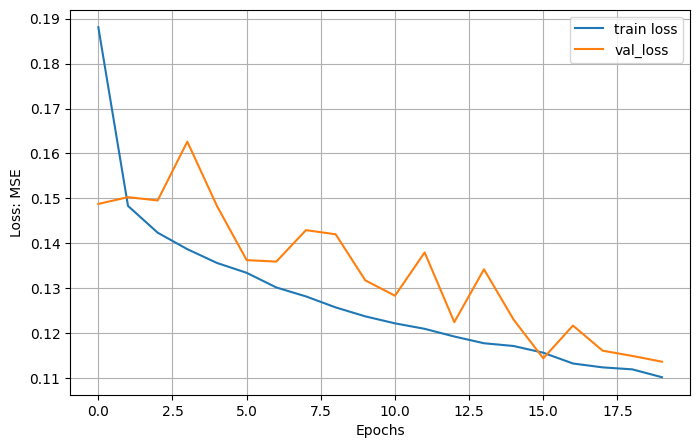

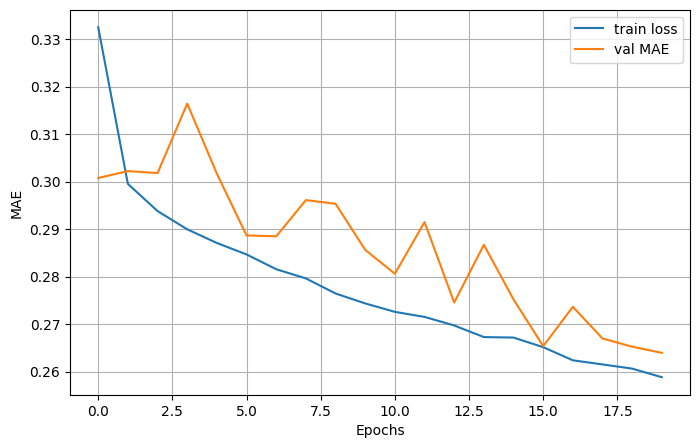

In [71]:
#Graficos 
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label="train loss")
plt.plot(history.history['val_loss'], label="val_loss")
plt.xlabel('Epochs')
plt.ylabel('Loss: MSE')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['mae'], label="train loss")
plt.plot(history.history['val_mae'], label="val MAE")
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

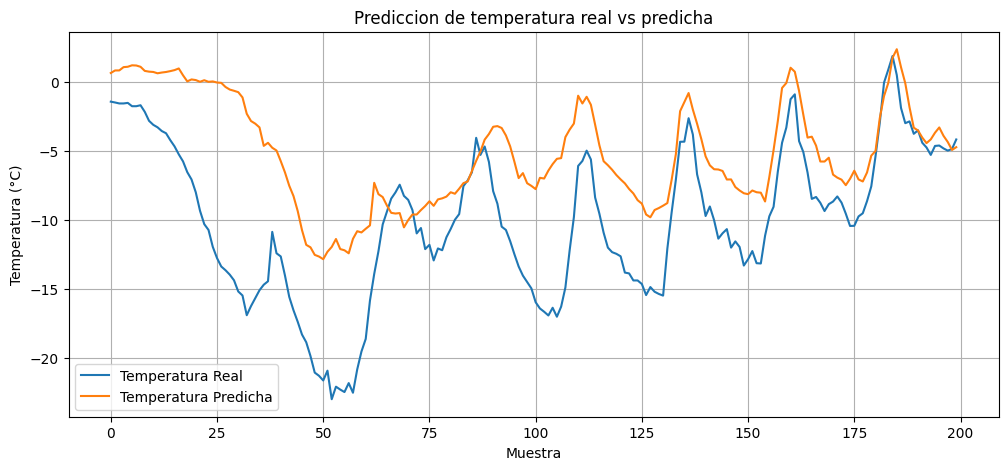

In [72]:
## Grafica que compare la tem real vs tem predicha 
plt. figure(figsize=(12,5))
plt.plot(y_test_real[:200], label='Temperatura Real')
plt.plot(y_pred_real[:200], label= 'Temperatura Predicha')
plt.title('Prediccion de temperatura real vs predicha')
plt.xlabel('Muestra')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.show()